![logo](img/logoitqv1.jpg)
<br>
# 0.1 PAO26-26 - Python 101, Descriptores de Textura
<br>

![python](img/python_logo.png)

<br>

*Kenin CUsme*

<br>

[link de Git Hub](https://github.com/kenin395/Machine-Learning.git)

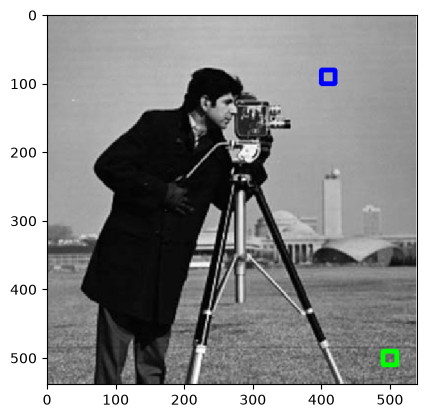

In [3]:
# En primer lugar, obtenemos la máscara de la imagen original mediante la␣umbralización con Otsu
import matplotlib.pyplot as plt
import cv2
import numpy as np
img = cv2.imread('images/photographer.png')
window = cv2.rectangle(img.copy(), (400,80), (420,100), (0, 0, 255), 5)
window = cv2.rectangle(window, (490,490), (510,510), (0, 255, 0), 5)
plt.imshow(window, cmap='gray')
plt.show()


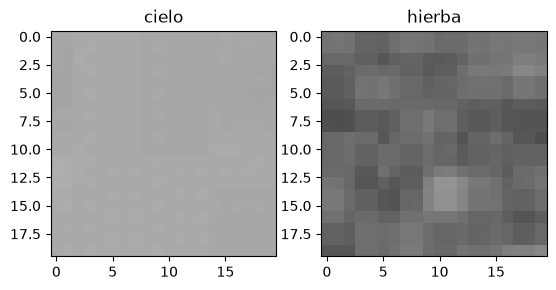

In [4]:
# Seleccionamos una región del cielo y una de la hierba
cielo = img[80:100, 400:420]
hierba = img[490:510, 490:510]
fig, ax = plt.subplots(1,2)
ax[0].imshow(cielo, cmap='gray')
ax[0].set_title('cielo')
ax[1].imshow(hierba, cmap='gray')
ax[1].set_title('hierba')
plt.show()


# 0.0.1 MATRIZ DE COOCURRENCIA

In [8]:
# MATRIZ DE COOCURRENCIA (Gray-Level Co-occurrence Matrix - GLCM)

import cv2
from tabulate import tabulate
from skimage.feature import graycomatrix, graycoprops

headers = ['', 'cielo', 'hierba']

CN = ['Contraste']
DIS = ['Disimilitud']
H = ['Homogeneidad']
ASM = ['ASM']
E = ['Energía']
COR = ['Correlación']

patches = [cielo, hierba]

for patch in patches:
    # Convertir la imagen a escala de grises
    image = cv2.cvtColor(patch, cv2.COLOR_BGR2GRAY)

    # Calcular la matriz de coocurrencia
    glcm = graycomatrix(
        image,
        distances=[5],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    # Extraer las propiedades
    CN.append(graycoprops(glcm, 'contrast')[0, 0])
    DIS.append(graycoprops(glcm, 'dissimilarity')[0, 0])
    H.append(graycoprops(glcm, 'homogeneity')[0, 0])
    ASM.append(graycoprops(glcm, 'ASM')[0, 0])
    E.append(graycoprops(glcm, 'energy')[0, 0])
    COR.append(graycoprops(glcm, 'correlation')[0, 0])

# Mostrar resultados
my_data = [CN, DIS, H, ASM, E, COR]

print(tabulate(my_data, headers=headers, tablefmt="grid"))

+--------------+----------+--------------+
|              |    cielo |       hierba |
+==============+==========+==============+
| Contraste    | 3.68     | 333.393      |
+--------------+----------+--------------+
| Disimilitud  | 1.4      |  13.8533     |
+--------------+----------+--------------+
| Homogeneidad | 0.512471 |   0.0921279  |
+--------------+----------+--------------+
| ASM          | 0.142717 |   0.00510556 |
+--------------+----------+--------------+
| Energía      | 0.377779 |   0.0714532  |
+--------------+----------+--------------+
| Correlación  | 0.190521 |  -0.0705127  |
+--------------+----------+--------------+


# 0.0.2 Scale-Invariant Feature Transform

(1672, 128)


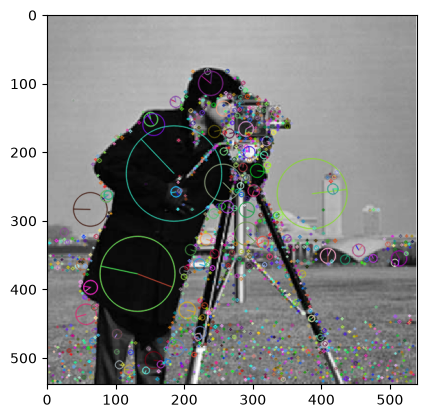

In [9]:
# SIFT algorithm
img = cv2.imread('images/photographer.png')
# Definición del algoritmo
sift = cv2.SIFT_create()
# Identificamos los puntos de interés
kp = sift.detect(img, None)
# Extraemos el descriptor para obtener el fingreprint
kp, des = sift.compute(img, kp)
print(np.shape(des))
# print(des) # Matriz donde las filas son los keypoints y las columnas las␣características de dichos puntos clave
# Visualizamos los puntos de interés
img=cv2.drawKeypoints(img, kp, img, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(img)
plt.show()


# 0.0.3 Histogram of Oriented Gradients

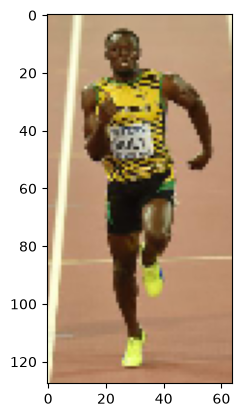

In [10]:
# HISTOGRAM OF ORIENTED GRADIENTS
# En primer lugar, obtenemos la máscara de la imagen original mediante la␣umbralización con Otsu
from skimage import io
img = io.imread('images/pedestrian.jpg')
img = np.float32(img/255)
crop = img[75:550,475:700]
crop = cv2.resize(crop, (64, 128))
plt.imshow(crop, cmap='gray')
plt.show()


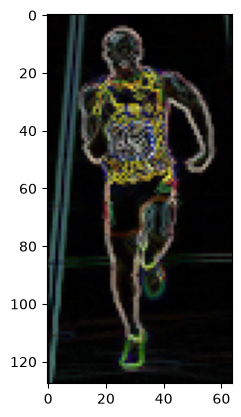

In [11]:
# Calculamos el gradiente con el kernel de Sobel
crop = np.float32(crop)
gx = cv2.Sobel(crop, cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(crop, cv2.CV_32F, 0, 1, ksize=1)
# Calculamos la magnitud y la dirección del gradiente
mag, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)
# Visualizamos la imagen obtenida en la magnitud del gradiente
mag = mag/np.max(mag)
plt.imshow(mag, cmap='gray')
plt.show()


In [15]:
import cv2
import numpy as np
from skimage.feature import hog

crop_gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

H = hog(
    crop_gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    transform_sqrt=True,
    block_norm='L1'
)

print(H.shape)

(3780,)


# 0.0.4 Local Binary Patterns


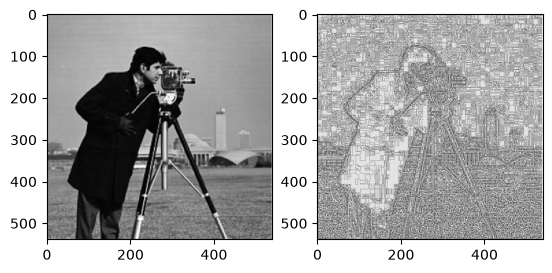

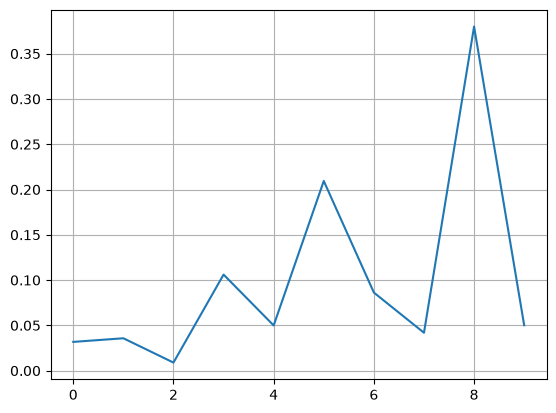

In [17]:
# LOCAL BINARY PATTERNS (LBP)
from skimage.feature import local_binary_pattern
img = cv2.imread('images/photographer.png')
# Definimos los parámetros iniciales
R = 1 # Radio
P = 8*R # Número de píxeles vecinos
epsilon = 1e-7 # Para normalizar el histograma
# Extraemos la imagen LBP
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
lbp_image = local_binary_pattern(img_gray, P, R, method='uniform')
a,b = np.unique(lbp_image, return_counts=True)
# Calculamos el histograma
lbp_image = np.uint8(lbp_image)
hist = cv2.calcHist([lbp_image.ravel()], [0], None, [P+2], [0, P+2])
# Normalizamos el histograma
hist = hist.astype("float")
hist /= (hist.sum() + epsilon)
# Los P+2=10 bins del histograma serán los 10 atributos que nos permitirán␣caracterizar una imagen
# Visualizamos la imagen LBP
figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray')
ax[1].imshow(lbp_image, cmap='gray')
plt.show()
# Visualizamos el histograma
plt.plot(hist)
plt.grid(True)
plt.show()
